In [1]:
import numpy as np
import analysis
import scipy.stats
import matplotlib.pyplot as plt
import RL

In [2]:
bj = analysis.Subject("ak", np.array([0.6, 0.8, 1]))
[alph, beta, gamma] = bj.train()
print(alph, beta, gamma)
bj._set_params(0.7, 15, 0.1)

Start!
True
1.0 0.0 0.3526368696401367


In [3]:
## Calculate accuracies for reinforcement learning
n = 50
acc_rl = np.zeros((n, 3))
for k in range(n):
    acc_k = bj.predict_RL()
    acc_rl[k, 0] = sum(acc_k[0]) / len(acc_k[0])
    acc_rl[k, 1] = sum(acc_k[1]) / len(acc_k[1])
    acc_rl[k, 2] = sum(acc_k[2]) / len(acc_k[2])

In [4]:
acc_sa = np.zeros((n, 3))
for k in range(n):
    acc_k = bj.predict_SA()
    acc_sa[k, 0] = sum(acc_k[0]) / len(acc_k[0])
    acc_sa[k, 1] = sum(acc_k[1]) / len(acc_k[1])
    acc_sa[k, 2] = sum(acc_k[2]) / len(acc_k[2])

<ErrorbarContainer object of 3 artists>

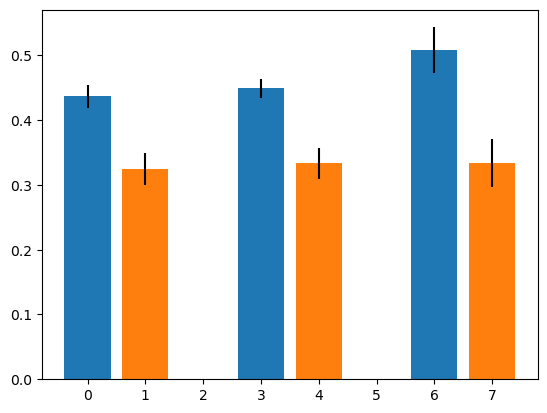

In [5]:
fig, ax = plt.subplots()
ax.bar(list(range(0,9,3)), np.mean(acc_rl, axis=0))
ax.bar(list(range(1, 10, 3)),  np.mean(acc_sa, axis=0))

ax.errorbar(list(range(0,9,3)), np.mean(acc_rl, axis=0), yerr=np.std(acc_rl, axis=0), 
             linestyle="", color='k')
ax.errorbar(list(range(1, 10, 3)), np.mean(acc_sa, axis=0), yerr=np.std(acc_sa, axis=0), 
             linestyle="", color='k')

qi=0.0
qi=0.0
qi=0.0
qi=0.8
qi=0.8
qi=0.8
qi=1.656
qi=1.656
qi=1.656
qi=0.28945889383341616
qi=0.28945889383341616
qi=0.28945889383341616
qi=0.9199665368203209
qi=0.9199665368203209
qi=0.9199665368203209
qi=1.1838483104243545
qi=1.1838483104243545
qi=1.1838483104243545
qi=0.9356105145028464
qi=0.9356105145028464
qi=0.9356105145028464
qi=0.4288237904358225
qi=0.4288237904358225
qi=0.4288237904358225
qi=1.412565002484228
qi=1.412565002484228
qi=1.412565002484228
qi=0.8344049627793556
qi=0.8344049627793556
qi=0.8344049627793556
qi=1.1927841051535872
qi=1.1927841051535872
qi=1.1927841051535872
qi=0.852018155396558
qi=0.852018155396558
qi=0.852018155396558
0.36363636363636365


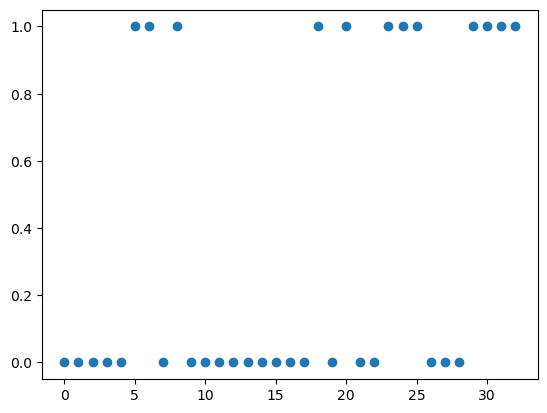

In [15]:
## test performance of rl model on task
def gen_features():
    INDEX = np.array([0, 1, 2, 3])
    stimuli_options = np.array([np.random.permutation(INDEX),  # color
                                    np.random.permutation(INDEX),  # shape
                                    np.random.permutation(INDEX)]) # pattern
    return stimuli_options.T

def acc_score(theta, p):
    alpha, beta, gamma = theta
    N = 100
    task_accuracy = np.zeros(N) # 1 if model selects correct feature
    rewards = np.zeros(N)       # 1 if model was rewarded by env
    # create agent
    test_agent = RL.FeatureRLDecay(alpha, beta, gamma)
    correct = (np.random.randint(0,3), np.random.randint(0,4))
    prev_cor=0

    for k in range(N):
        test_agent.set_action(gen_features())

        test_agent.set_q()

        a_k_idx = test_agent.select_stim()
  
        if test_agent.actions[a_k_idx][correct[0]] == correct[1]:
            task_accuracy[k] = 1
            prev_cor+=1
            if np.random.random() < p:
                rewards[k] = 1
                test_agent.update_v(a_k_idx, 1)
                # print("Rewarded!")
            else:
                test_agent.update_v(a_k_idx, 0)
        else:
            test_agent.update_v(a_k_idx, 0)
            prev_cor = 0
        # print("V-table after update: " + str(test_agent.v_feature))
        # print("New Choice!")
        if prev_cor >= 5:
            task_accuracy = task_accuracy[:k]
            return task_accuracy
    return N


choices = acc_score([0.8, 15, 0.1], .8)
print(np.sum(choices)/len(choices))
plt.plot(choices, 'o')

In [ ]:
## tune optimal hyperparameters for RL model

# loss = lambda theta: acc_score(theta, 1) #poorly behaved function! bad function!

# from scipy.optimize import minimize
# res = minimize(loss, x0 = [0.8, 15, 1], 
#                  bounds = [(0, 1), (0, None), (0,1)], method='Nelder-Mead')
# print(res.success)

# alpha, beta, gamma = res.x
# print(alpha, beta, gamma)